# DSA 4060 Week 1 Practical: Popularity-Based Movie Recommender

**Student:** Abdirisak Hussein  
**Student number:** *668776*  
**Date:** 20 September 2026  

## Purpose
This notebook explores MovieLens user-item ratings and builds two non-personalized movie recommendation baselines:
1. A minimum-rating popularity recommender.
2. A weighted-rating recommender.

The methods are transparent baselines for future personalized recommender systems.


## 1. Import libraries and configure paths

In [1]:
from pathlib import Path
import zipfile
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = PROJECT_ROOT / "images"
DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / "movies.csv"
RATINGS_FILE = DATA_DIR / "ratings.csv"


if not MOVIES_FILE.exists() or not RATINGS_FILE.exists():
    url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    zip_path = DATA_DIR / "ml-latest-small.zip"
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    extracted = DATA_DIR / "ml-latest-small"
    MOVIES_FILE.write_bytes((extracted / "movies.csv").read_bytes())
    RATINGS_FILE.write_bytes((extracted / "ratings.csv").read_bytes())
    readme = extracted / "README.txt"
    if readme.exists():
        (DATA_DIR / "README.txt").write_bytes(readme.read_bytes())

movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)


Movies shape: (9742, 3)
Ratings shape: (100836, 4)


## 2. Inspect and validate the data

In [2]:
display(movies.head())
display(ratings.head())

print("Movies information:")
movies.info()

print("\nRatings information:")
ratings.info()

print("\nMissing values in movies:")
print(movies.isna().sum())

print("\nMissing values in ratings:")
print(ratings.isna().sum())

print("Duplicate movie rows:", movies.duplicated().sum())
print("Duplicate rating rows:", ratings.duplicated().sum())
print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())
print("Unknown movie IDs:", (~ratings["movieId"].isin(movies["movieId"])).sum())


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Movies information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

Ratings information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate movie rows: 0
Dupli

### Interpretation
The validation output checks whether the expected columns are available, whether missing values exist, whether duplicate rows are present, whether ratings fall within the expected scale, and whether every rated movie has a matching record in `movies.csv`. Duplicate rows should be investigated based on the dataset definition rather than automatically deleted.


## 3. Summarize user-item interactions

In [3]:
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_interactions = len(ratings)

print("Unique users:", n_users)
print("Movies with at least one rating:", n_movies_rated)
print("Total rating interactions:", n_interactions)
display(ratings["rating"].describe())


Unique users: 610
Movies with at least one rating: 9724
Total rating interactions: 100836


,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


The number of unique users counts distinct `userId` values. The number of movies with at least one rating counts distinct `movieId` values in the ratings table, which can be smaller than the number of movies listed in `movies.csv`. Total interactions is the number of rating records.


## 4. Explore interactions and rating distribution

Ratings per user:


,0
count,610.000000
mean,165.304918
std,269.480584
min,20.000000
25%,35.000000
50%,70.500000
75%,168.000000
max,2698.000000


Ratings per movie:


,0
count,9724.000000
mean,10.369807
std,22.401005
min,1.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,329.000000


,count
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


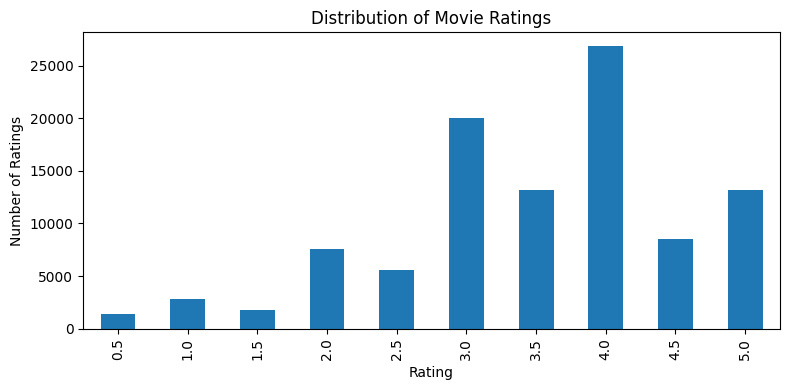

In [4]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

print("Ratings per user:")
display(ratings_per_user.describe())

print("Ratings per movie:")
display(ratings_per_movie.describe())

rating_distribution = ratings["rating"].value_counts().sort_index()
display(rating_distribution)

ax = rating_distribution.plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribution of Movie Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
plt.tight_layout()
plt.show()


### Interpretation
The rating-distribution chart shows which rating values occur most frequently.

## 5. Calculate interaction-matrix sparsity

In [5]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f"Possible interactions: {possible_interactions:,}")
print(f"Observed interactions: {observed_interactions:,}")
print(f"Sparsity: {sparsity:.2%}")


Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


Sparsity represents the proportion of possible user-movie combinations for which no rating was observed. A high value means that the user-item matrix is mostly empty. This popularity baseline does not try to infer individual preferences for those empty cells.


## 6. Build the minimum-rating popularity recommender

In [6]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left",
    validate="one_to_one"
)

display(movie_stats.head())

most_rated = (
    movie_stats
    .sort_values(["rating_count", "average_rating"], ascending=[False, False])
    .head(10)
)
print("Most rated movies:")
display(most_rated[["title", "rating_count", "average_rating"]])

highest_average = (
    movie_stats
    .sort_values(["average_rating", "rating_count"], ascending=[False, False])
    .head(10)
)
print("Highest average-rated movies:")
display(highest_average[["title", "rating_count", "average_rating"]])


,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


Most rated movies:


,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


Highest average-rated movies:


,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


The most-rated list measures visibility or engagement rather than necessarily measuring quality. The highest-average list can be dominated by movies with very few ratings, so here; average rating alone can be misleading.


In [7]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats["rating_count"] >= MIN_RATINGS]
    .sort_values(["average_rating", "rating_count"], ascending=[False, False])
    .head(10)
)

display(popular_movies[["title", "genres", "rating_count", "average_rating"]])

def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats["rating_count"] >= min_ratings].copy()
    return (
        candidates
        .sort_values(["average_rating", "rating_count"], ascending=[False, False])
        .head(top_n)
        [["movieId", "title", "genres", "rating_count", "average_rating"]]
    )

recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)


,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


## 7. Build a weighted-rating recommender

In [8]:
C = ratings["rating"].mean()
m = movie_stats["rating_count"].quantile(0.90)

print(f"Overall mean rating C: {C:.3f}")
print(f"90th percentile rating count m: {m:.1f}")

qualified = movie_stats[movie_stats["rating_count"] >= m].copy()
v = qualified["rating_count"]
R = qualified["average_rating"]

qualified["weighted_score"] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified
    .sort_values(["weighted_score", "rating_count"], ascending=[False, False])
    .head(10)
)

display(weighted_recommendations[
    ["title", "genres", "rating_count", "average_rating", "weighted_score"]
])


Overall mean rating C: 3.502
90th percentile rating count m: 27.0


,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


The weighted score combines a movie's average rating with the overall average. Movies with fewer ratings are pulled closer to the overall mean, while movies with many ratings are influenced more strongly by their own average. The 90th percentile threshold is a transparent policy choice.


## 8. Compare the two recommendation lists

In [9]:
comparison = popular_movies[["title", "rating_count", "average_rating"]].copy()
comparison["method"] = "Minimum 50 ratings"

weighted_view = weighted_recommendations[
    ["title", "rating_count", "average_rating"]
].copy()
weighted_view["method"] = "Weighted score"

display(pd.concat([comparison, weighted_view], ignore_index=True))

print("Titles appearing in both lists:")
print(sorted(set(popular_movies["title"]).intersection(
    set(weighted_recommendations["title"])
)))


,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


Titles appearing in both lists:
['Fight Club (1999)', 'Godfather, The (1972)', 'Godfather: Part II, The (1974)', 'Shawshank Redemption, The (1994)']


## 9. Visualize the weighted recommendations

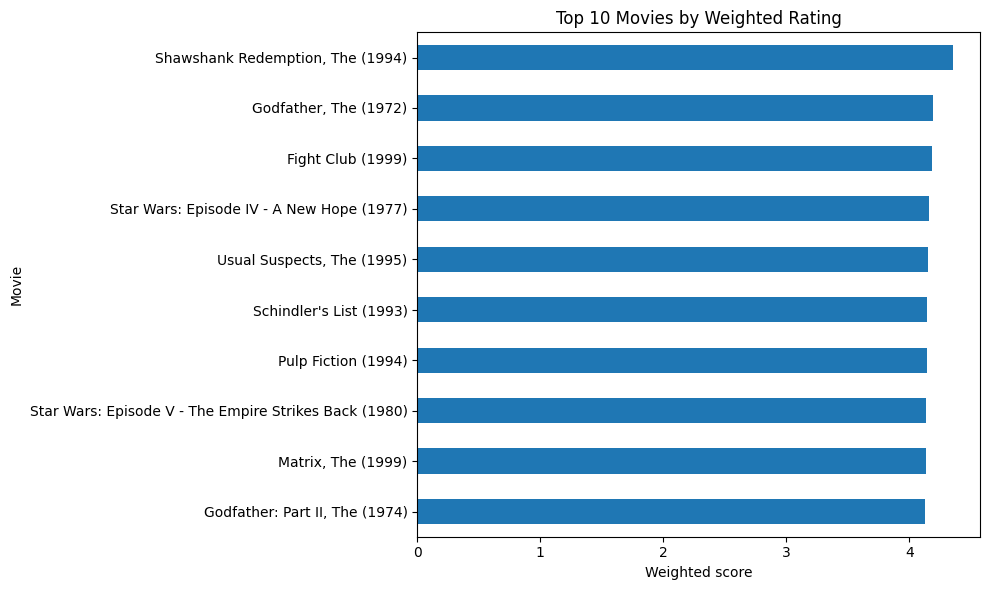

In [10]:
plot_data = weighted_recommendations.sort_values("weighted_score")

ax = plot_data.plot(
    x="title",
    y="weighted_score",
    kind="barh",
    figsize=(10, 6),
    legend=False
)
ax.set_title("Top 10 Movies by Weighted Rating")
ax.set_xlabel("Weighted score")
ax.set_ylabel("Movie")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "top10_recommendations.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Test the output

In [11]:
assert len(recommendations) <= 10
assert recommendations["movieId"].is_unique
assert recommendations["rating_count"].ge(50).all()
assert recommendations["average_rating"].between(0.5, 5.0).all()
assert recommendations["title"].notna().all()
assert len(weighted_recommendations) <= 10
assert weighted_recommendations["weighted_score"].notna().all()

print("All checks passed.")


All checks passed.


## 11. Parameter sensitivity and optional genre filter

In [12]:
print("Minimum threshold = 20:")
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))

print("Minimum threshold = 100:")
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    mask = stats["genres"].str.contains(genre, case=False, na=False)
    return recommend_popular_movies(stats[mask], min_ratings, top_n)

print("Comedy recommendations:")
display(recommend_by_genre(movie_stats, "Comedy", 30, 10))


Minimum threshold = 20:


,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


Minimum threshold = 100:


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


Comedy recommendations:


,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


A lower threshold admits more movies but may make rankings less stable because fewer ratings support the averages. A higher threshold favors widely rated movies but may exclude less-known movies. The genre filter remains non-personalized because all users requesting the same genre receive the same ranking.


## 12. Findings and Limitations

The MovieLens dataset contains explicit user feedback in the form of movie ratings. The analysis first summarizes users, movies, and rating interactions, then aggregates ratings by movie using the average rating and the number of ratings. Rating count indicates how frequently a movie was rated, while average rating summarizes the observed level of approval. These measures answer different questions: a highly rated movie is not necessarily widely watched or rated, and a widely rated movie may have a moderate average rating.

The minimum-rating recommender uses a threshold of 50 ratings before ranking movies by average rating. This reduces the chance that a movie with only a few ratings appears at the top because of an unstable average. The weighted-rating recommender applies a second approach. It combines each movie's average rating with the overall dataset mean and gives more influence to movies with larger rating counts. The 90th percentile of rating count is used as the evidence threshold, meaning that the qualified candidates are approximately the most frequently rated movies.

Several limitations remain. First, the recommender is not personalized: every user receives the same list and the model does not use an individual's rating history, genre preferences, or previous interactions. Second, popularity bias can repeatedly promote already-visible movies while giving less exposure to niche, recent, or less frequently rated titles. Third, new movies with no ratings face a cold-start problem because their average rating and rating count are unavailable. Fourth, preferences can change over time, but this baseline does not model recency or changing tastes. Finally, a numerical rating does not explain why a user liked or disliked a movie, and the system does not evaluate diversity, novelty, coverage, or recommendation quality using a train-test split.

Overall, these methods are useful as transparent baselines. Future versions could use content-based filtering with genres and text, collaborative filtering from user-rating patterns, temporal features, and evaluation metrics such as precision, recall, coverage, and diversity.


## 13. Reflection Questions

1. **What did the popularity baseline do well?** It produced a simple, transparent, and reproducible list without requiring individual user histories.
2. **Which users or movies might be disadvantaged?** Users with niche interests and movies with few ratings may receive less relevant exposure.
3. **What additional data is needed for personalization?** User rating history, clicks, watch time, skips, genres, timestamps, and possibly contextual information.
4. **Which result would you use as the home-page baseline and why?** The weighted-rating list is a defensible baseline because it considers both rating quality and evidence volume.
5. **What will you change next?** Add content-based or collaborative filtering and evaluate the system using held-out interactions.
